# Calculating real airflow values from pressure data around the radiators

### Logic overview:

- Pressure sensor tubes oriented parallel to flow of air and radiator direction; they therefore measure dynamic pressure.
- Dynamic pressure is given by the formula: $P=\frac{1}{2} \rho v^2$
- By rearranging the formula, we can calculate the velocity of air passing around the radiator: $\sqrt{\frac{2P}{\rho}} = v_{air}$
- The tests were done at a constant speed of 50 km/h.

### Imports

In [65]:
import csv
import re
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

### Conveerting to .csv

In [66]:
input_file = "data_files/DATA_RAD.TXT"
output_file = "processed_data/rad_airflow_raw.csv"

channel_re = re.compile(r"Channel\s+(\d+)")
pressure_re = re.compile(r"Pressure reading:\s*([0-9.]+)")
time_re = re.compile(r"(\d{4}/\d{2}/\d{2}.*)")

data = []
current = {}

with open(input_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        m = channel_re.match(line)
        if m:
            if current:
                data.append(current)
                current = {}
            current["Channel"] = m.group(1)
            continue

        m = pressure_re.match(line)
        if m:
            current["Pressure"] = m.group(1)
            continue

        m = time_re.match(line)
        if m:
            full_timestamp = m.group(1)
            cleaned = re.sub(r"\([^)]*\)\s*", "", full_timestamp)
            dt = datetime.strptime(cleaned, "%Y/%m/%d %H:%M:%S")
            current["Time"] = dt.isoformat(sep=" ")
            continue

    if current:
        data.append(current)

with open(output_file, "w", newline="") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=["Channel", "Time", "Pressure"])
    writer.writeheader()
    writer.writerows(data)

### Plot

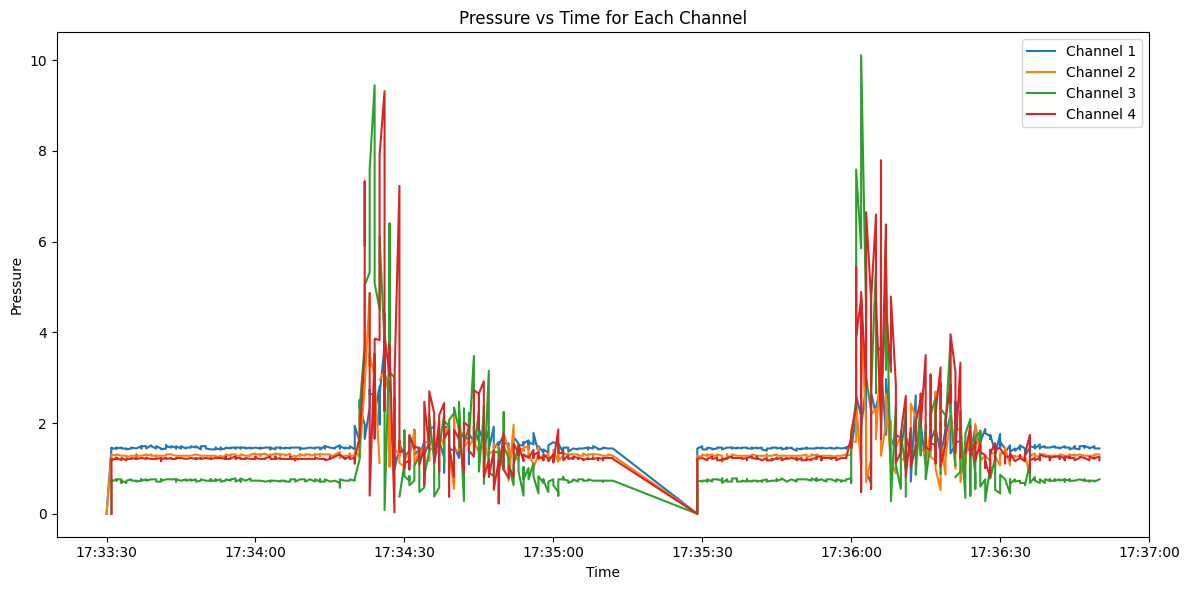

In [67]:
df = pd.read_csv("processed_data/rad_airflow_raw.csv")
df["Channel"] = df["Channel"].astype(str)
df["Time"] = pd.to_datetime(df["Time"])
plt.figure(figsize=(12, 6))
for channel in sorted(df["Channel"].unique(), key=lambda x: int(x)):
    channel_df = df[df["Channel"] == channel]
    plt.plot(channel_df["Time"], channel_df["Pressure"], label=f"Channel {channel}")

plt.xlabel("Time")
plt.ylabel("Pressure")
plt.title("Pressure vs Time for Each Channel")
plt.legend()
plt.tight_layout()
plt.show()

### Dropping stationary values and returns

In [68]:
cutoff_time = pd.to_datetime("2025-11-16 17:35:30")
df_before = df[df["Time"] <= cutoff_time]
df_after  = df[df["Time"] > cutoff_time]

df_dict = {"Run 1" :df_before, "Run 2" :df_after}

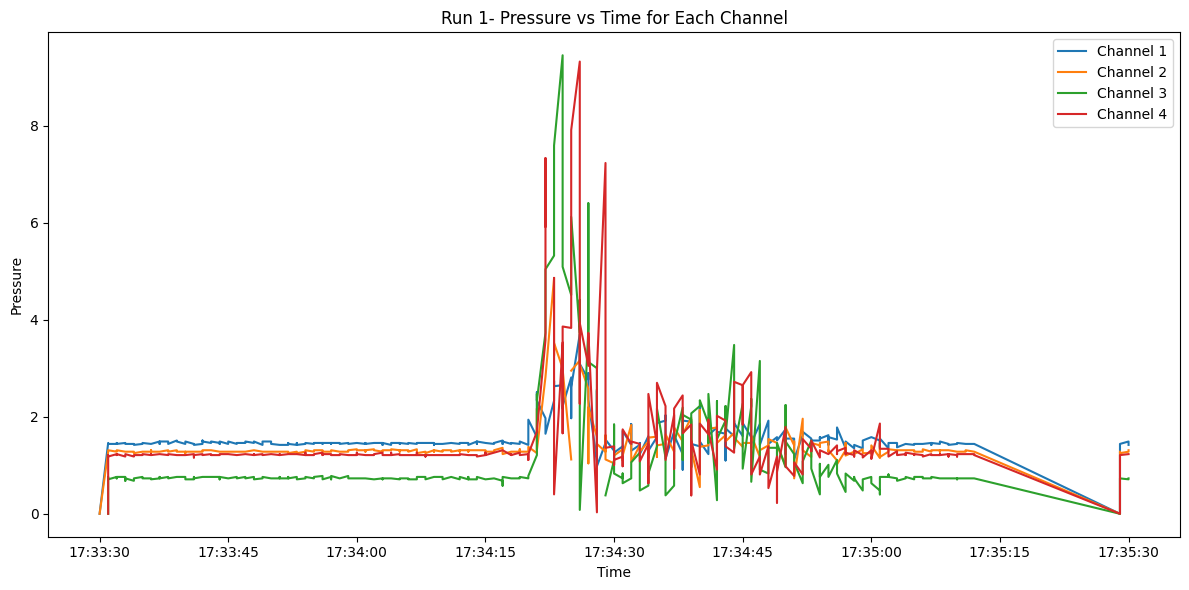

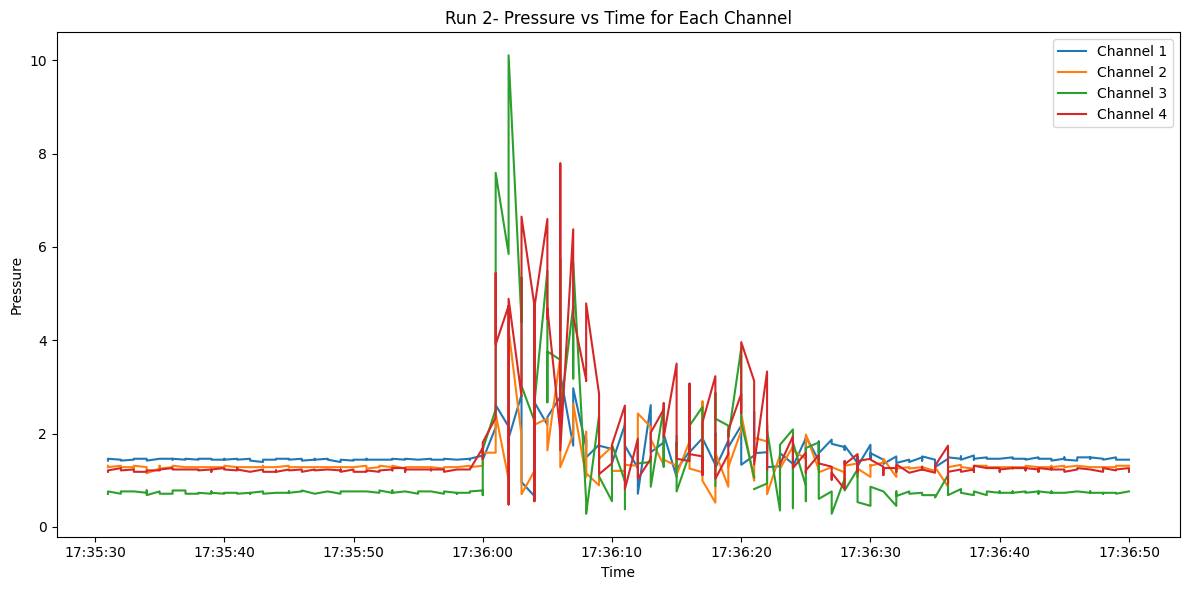

In [69]:
for name, df in df_dict.items():

    plt.figure(figsize=(12, 6))
    for channel in sorted(df["Channel"].unique(), key=lambda x: int(x)):
        channel_df = df[df["Channel"] == channel]
        plt.plot(channel_df["Time"], channel_df["Pressure"], label=f"Channel {channel}")

    plt.xlabel("Time")
    plt.ylabel("Pressure")
    plt.title(f"{name}- Pressure vs Time for Each Channel")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Isolating the constant speed data (~3 seconds)

In [70]:
df = pd.read_csv("processed_data/rad_airflow_raw.csv")
df["Time"] = pd.to_datetime(df["Time"])

start_before = pd.to_datetime("2025-11-16 17:34:23")
end_before   = pd.to_datetime("2025-11-16 17:34:26")
df_before_trim = df[(df["Time"] >= start_before) & (df["Time"] <= end_before)]

start_after = pd.to_datetime("2025-11-16 17:36:02")
end_after   = pd.to_datetime("2025-11-16 17:36:05")
df_after_trim = df[(df["Time"] >= start_after) & (df["Time"] <= end_after)]

df_dict = {"Run 1" :df_before_trim, "Run 2" :df_after_trim}


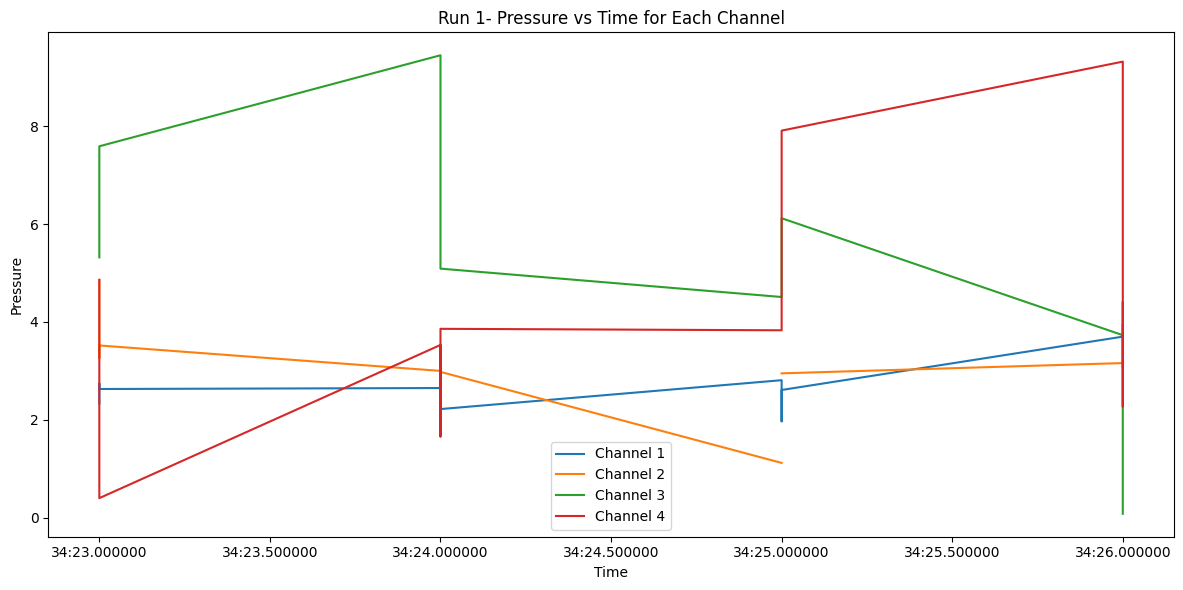

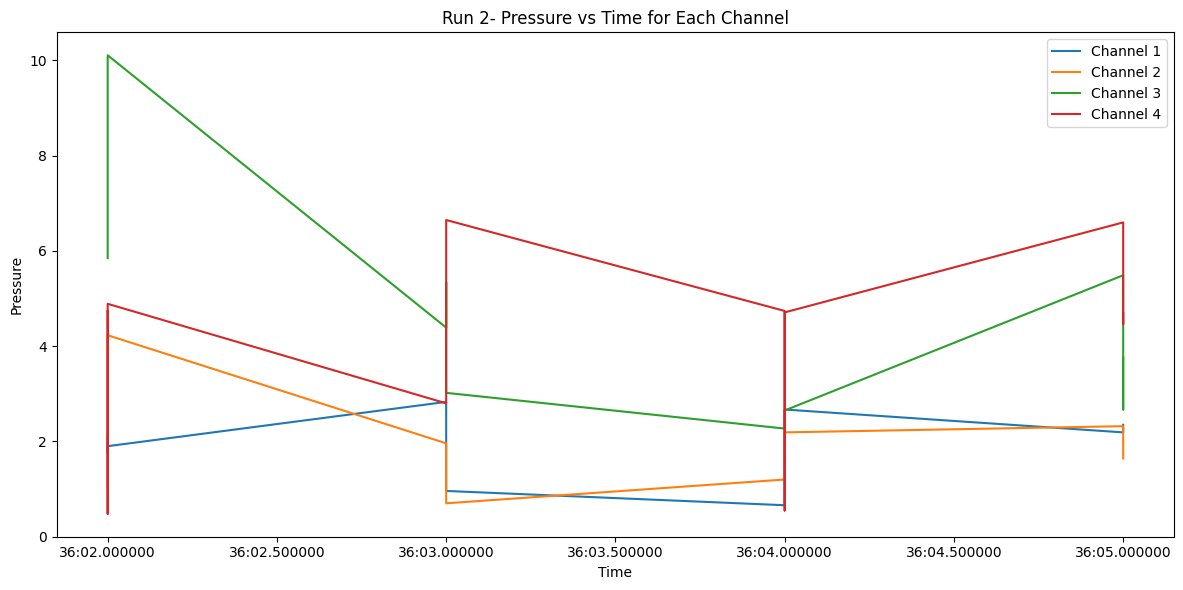

In [71]:
for name, df in df_dict.items():

    plt.figure(figsize=(12, 6))
    for channel in sorted(df["Channel"].unique(), key=lambda x: int(x)):
        channel_df = df[df["Channel"] == channel]
        plt.plot(channel_df["Time"], channel_df["Pressure"], label=f"Channel {channel}")

    plt.xlabel("Time")
    plt.ylabel("Pressure")
    plt.title(f"{name}- Pressure vs Time for Each Channel")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Taking mean and converting to velocity

In [72]:
air_rho = 1.066 #kg/m3
for name, df in df_dict.items():
    mean_pressure = df["Pressure"].mean()
    mean_velocity = (((2*mean_pressure)/air_rho)**(1/2))*3.6
    velocity_percent = 100*(mean_velocity/50)

    print(f"{name} Mean velocity: {mean_velocity:.2f} km/h")
    print(f"{name} Air flow percentage: {velocity_percent:.2f}%")

Run 1 Mean velocity: 9.64 km/h
Run 1 Air flow percentage: 19.28%
Run 2 Mean velocity: 8.82 km/h
Run 2 Air flow percentage: 17.64%
